In [1]:
import numpy as np
from bhjet import BLJet
import matplotlib.pyplot as plt
%matplotlib widget

make a new BLJet object, all these parameters are optional and will otherwise have default values

In [ ]:
bljet = BLJet(
    mass_bh=1e9, # M_sun
    jet_power_eddington=1e-5, # in units of the Eddington Luminosity
    z_jet_launching=2, # in units of rg
    r_initial=3, # in units of rg
    z_end_of_acceleration=1e5, # in units of rg
    z_dissipation=1e2, # in units of rg
    z_max_calculation=1e6, # in units of rg
    sigma_final=1,
    gamma_final=10, # Lorentz factor
    electron_temperature_jet_base=1e1, # keV
    gamma_acceleration_exponent=0.5,
    opening_angle_constant=0.15,
    calc_pair_content_from_plasma_beta=False,
    plasma_beta_jet_base=1, # ignored if above == False
    n_zones=100,
    verbosity_level=1
)

These parameters can be accessed also as variables

In [3]:
print(bljet.gamma_final)
bljet.gamma_final = 9
print(bljet.gamma_final)

10.0
9.0


It is also posible to read out the graviational radius and 

In [4]:
f"{bljet.r_g:.1e} cm, {bljet.eddington_luminosity:.1e} erg/s"

'0.0e+00 cm, 0.0e+00 erg/s'

Using these parameters the jet dynamics can be computed

In [5]:
bljet.compute_jet_dynamics()

Then the various quantities can be read out

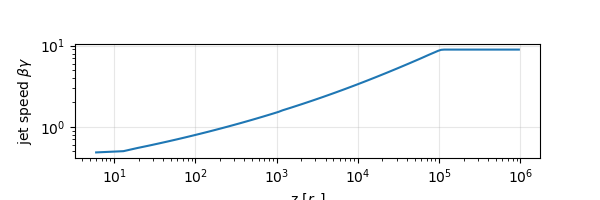

In [6]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, bljet.get_beta_gamma_grid())
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"jet speed $\beta\gamma$")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

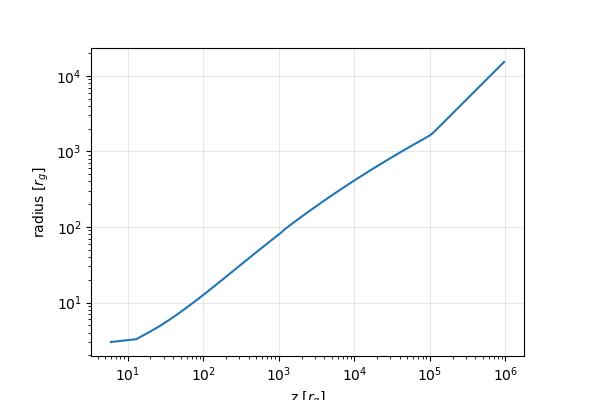

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, bljet.get_radius_grid()/bljet.r_g)
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"radius [$r_g$]")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

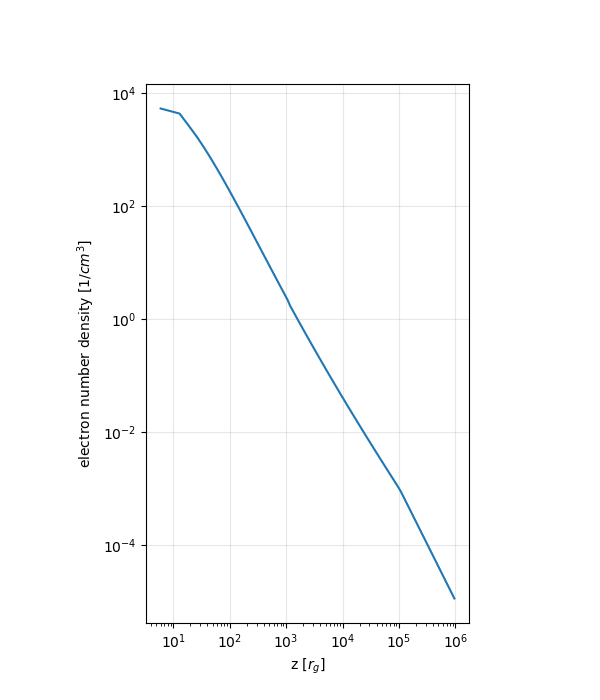

In [8]:
fig, ax = plt.subplots(figsize=(6, 7))
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, bljet.get_electron_density_grid())
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"electron number density [$1/cm^3$]")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

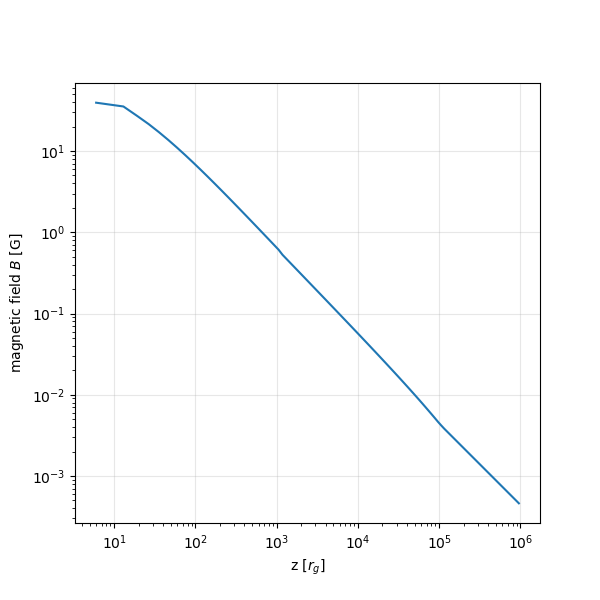

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, bljet.get_magnetic_field_grid())
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"magnetic field $B$ [G]")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

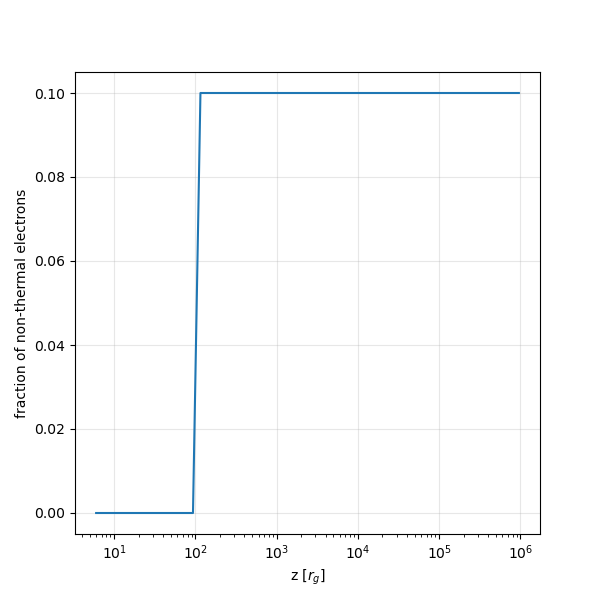

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.semilogx(bljet.get_z_center_grid()/bljet.r_g, bljet.get_fraction_nonthermal_electrons_grid())
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"fraction of non-thermal electrons")
# ax.set_aspect("equal")
ax.grid(alpha=0.3)

visualize the Bernoulli eq.

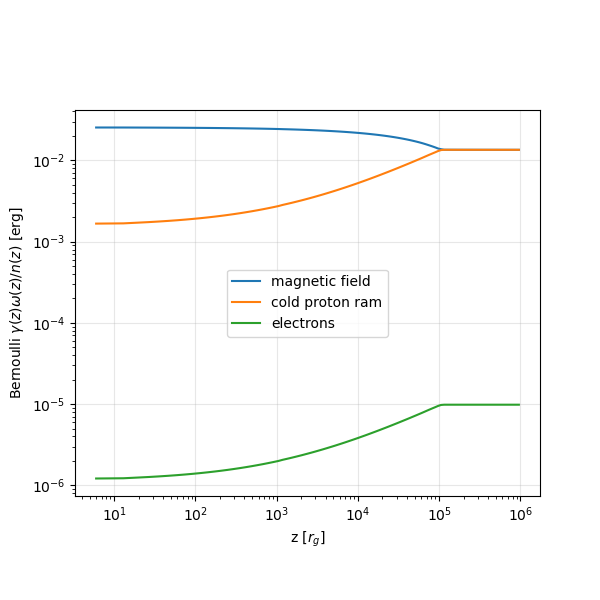

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

# magn. enthalpy (energy density + pressure): B(z)^2 / 4pi
w_B = bljet.get_magnetic_field_grid()**2/4/np.pi
# cold proton enthalpy (pressure): n(z) * m_p*c^2 
mpc2_erg = 1.5e-3
w_p = bljet.get_electron_density_grid() * mpc2_erg
# electron enthalpy (energy density + pressure): n(z) * Gamma_adi * m_e*c^2 * <gamma_el>
Gamma_adi = 4/3
mec2_erg = 8.2e-7
gamma_el_av = bljet.get_electron_temperature_grid() # approximation up to order unity factor
w_e = bljet.get_electron_density_grid() * Gamma_adi * mec2_erg
# bulk gamma / density
gamma_n =  bljet.get_gamma_grid() / bljet.get_electron_density_grid()

ax.loglog(bljet.get_z_center_grid()/bljet.r_g, gamma_n * w_B, label="magnetic field")
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, gamma_n * w_p, label="cold proton ram")
ax.loglog(bljet.get_z_center_grid()/bljet.r_g, gamma_n * w_e, label="electrons")
ax.set_xlabel(r"z [$r_g$]")
ax.set_ylabel(r"Bernoulli $\gamma(z) \omega(z) / n(z)$ [erg]")
ax.legend(loc="center")
ax.set_aspect("equal")
ax.grid(alpha=0.3)